In [5]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, Subset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [3]:
model = CNN(width=8, bn=True, normalise=False)
device = torch.device("mps")
weights_path = TRAINING_RESULTS/'low_mass'/'run_100426_131113'/'best_model_weights.pth'
#weights_path = TRAINING_RESULTS/'low_mass'/ 'good_runs' /'run_090326_150123'/'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Plotter

In [37]:
results_path = TRAINING_RESULTS/'low_mass'/ 'good_runs' /'run_090326_165434'/'results.pt'
results = torch.load(results_path)
iters, train_loss, train_soft_acc, val_soft_acc,\
          train_hard_acc, val_hard_acc, test_soft_acc, test_hard_acc= results

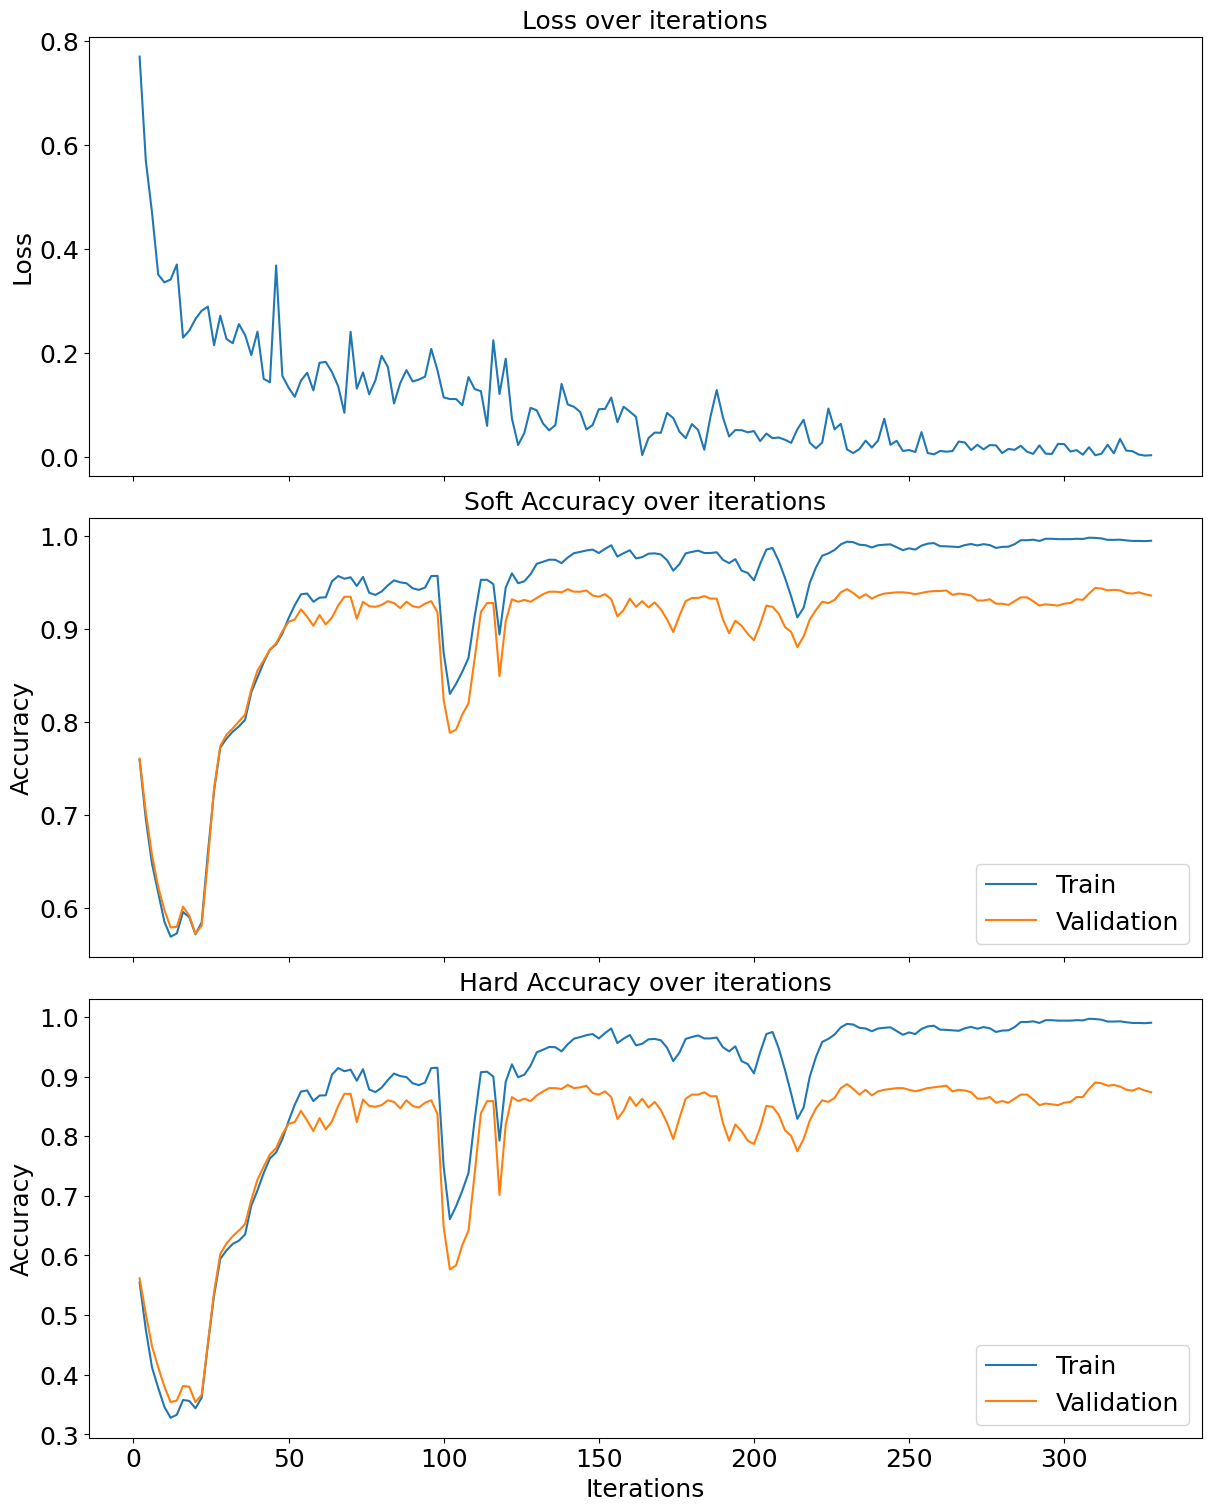

In [38]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 15), constrained_layout=True)

axes[0].plot(iters[:len(train_loss)], train_loss)
axes[0].set_title("Loss over iterations",  fontsize=18)
axes[0].set_ylabel("Loss",  fontsize=18)
axes[0].tick_params(axis='y', labelsize=18)

axes[1].plot(iters[:len(train_soft_acc)], train_soft_acc)
axes[1].plot(iters[:len(val_soft_acc)], val_soft_acc)
axes[1].set_title("Soft Accuracy over iterations", fontsize=18)
axes[1].set_ylabel("Accuracy",  fontsize=18)
axes[1].legend(["Train", "Validation"],  fontsize=18)
axes[1].tick_params(axis='y', labelsize=18)

axes[2].plot(iters[:len(train_hard_acc)], train_hard_acc)
axes[2].plot(iters[:len(val_hard_acc)], val_hard_acc)
axes[2].set_title("Hard Accuracy over iterations",  fontsize=18)
axes[2].set_xlabel("Iterations",  fontsize=18)
axes[2].set_ylabel("Accuracy",  fontsize=18)
axes[2].legend(["Train", "Validation"],  fontsize=18)

axes[2].tick_params(axis='x', labelsize=18)
axes[2].tick_params(axis='y', labelsize=18)
plt.show()

## Confusion matrix

In [6]:
dataset = LISADataset(training_lm_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [8]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1].to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

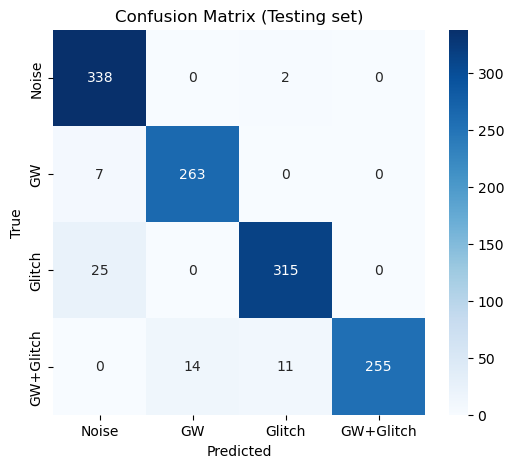

In [9]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [19]:
np.where((true_class == 3)&(pred_class == 3))[0][0:40]

array([610, 611, 612, 613, 614, 615, 616, 617, 618, 620, 621, 622, 623,
       624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636,
       637, 638, 639, 640, 641, 642, 643, 644, 645, 646, 647, 648, 649,
       650])

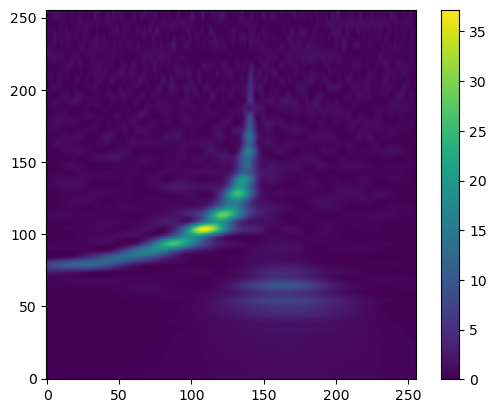

True label: tensor([1., 1.])
Sim index: 49
Time index: 3


In [18]:
image, label, sim_index, time_index = test_dataset[643]
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)